<h2 style="color: #ff007f; font-size: 26px; text-align: center; margin-top: 20px; margin-bottom: 5px; font-family: 'Segoe UI', sans-serif; font-weight: 600;">EBS & PIXE Data Comparison</h2>
<p style="color: #ff007f; text-align: center; margin-top: 0; margin-bottom: 25px; font-size: 14px; font-weight: bold; text-transform: uppercase; letter-spacing: 1px;">José Sousa-Brito</p>


To run this script on a new dataset, you only need to update the source path variable at the top of the file:

### 1. Target File Path

Provide the absolute path to your raw `.dat` text file. The script uses `latin-1` encoding to handle special characters without breaking:

```python
file_path = r"C:\Users\joseb\Desktop\...\671f0102.dat"
```

### 2. Main Parameters & Visual Layout

The internal layout handles formatting automatically, but these core values control the structure if you need to adjust them directly in the code:

- **bar_height (0.38):** Controls the thickness and separation of the horizontal bars.
- **max_val \* 17.5:** Automatically expands the right boundary limit to ensure the legend never overlaps the longest data bars.

Success! Vector PDF generated successfully: PIXE_EBS_GRAPH.pdf


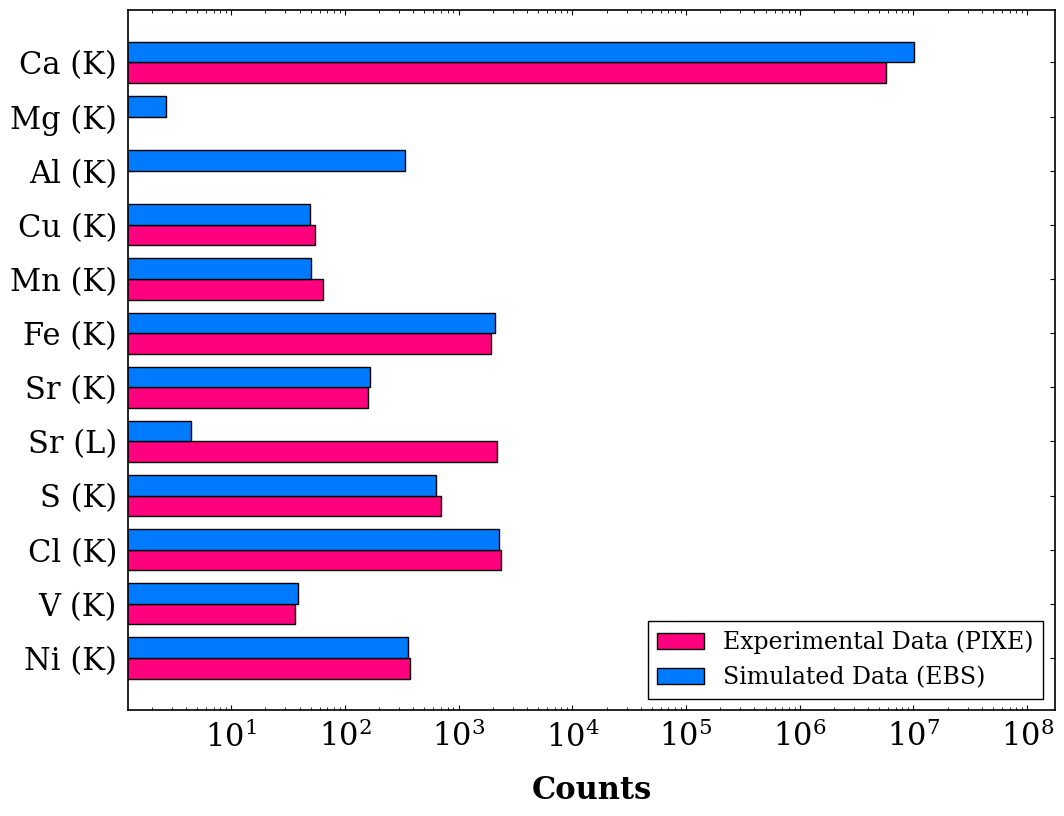

In [2]:
import matplotlib.pyplot as plt
import numpy as np

file_path = r"C:\Users\joseb\Desktop\Analise_Jose\Espectros_EBS\1965 keV\Foraminiferos\671131\671f0102.dat" 

def plot_ebs_article_quality_pdf(path):
    elements, experimental_counts, simulated_counts = [], [], []
    
    try:
        with open(path, 'r', encoding='latin-1') as f:
            lines = f.readlines()
        
        start_parsing = False
        for line in lines:
            if "element" in line and "data" in line:
                start_parsing = True
                continue
            
            if start_parsing:
                parts = line.split()
                if len(parts) >= 5:
                    label = f"{parts[0]} ({parts[1].replace(':', '')})"
                    elements.append(label)
                    experimental_counts.append(float(parts[2]))
                    simulated_counts.append(float(parts[4]))

        plt.rcParams.update({
            'font.size': 18,              
            'font.family': 'serif',
            'axes.labelweight': 'bold',
            'axes.linewidth': 1.2,     
            'pdf.fonttype': 42,
            'xtick.labelsize': 22,    
            'ytick.labelsize': 22,       
        })

        fig, ax = plt.subplots(figsize=(11, 8.5)) 
        y_pos = np.arange(len(elements))
        bar_height = 0.38

        ax.barh(y_pos + bar_height/2, experimental_counts, bar_height, 
                label='Experimental Data (PIXE)', color='#ff007f', 
                edgecolor='black', linewidth=1)

        ax.barh(y_pos - bar_height/2, simulated_counts, bar_height, 
                label='Simulated Data (EBS)', color='#007bff', 
                edgecolor='black', linewidth=1)

        ax.set_xscale('log')
        ax.set_yticks(y_pos)
        ax.set_yticklabels(elements)
        
        ax.set_xlabel('Counts', fontsize=22, labelpad=15)
        
        ax.invert_yaxis()
        
        max_val = max(max(experimental_counts), max(simulated_counts))
        ax.set_xlim(left=None, right=max_val * 17.5)

        ax.tick_params(axis='both', which='both', direction='in', top=True, right=True, pad=8)

        for spine in ax.spines.values():
            spine.set_visible(True)
            spine.set_color('black')

        ax.legend(loc='lower right', frameon=True, edgecolor='black', 
                  framealpha=1, fancybox=False, fontsize=17)
        
        plt.tight_layout()
        
        output_name = "PIXE_EBS_GRAPH.pdf"
        plt.savefig(output_name, format='pdf', bbox_inches='tight', transparent=True)
        
        print(f"Success! Vector PDF generated successfully: {output_name}")
        plt.show()

    except Exception as e:
        print(f"An error occurred: {e}")

if __name__ == "__main__":
    plot_ebs_article_quality_pdf(file_path)